<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Outlier_Detection_Percentile_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Outlier Deetection using percentile

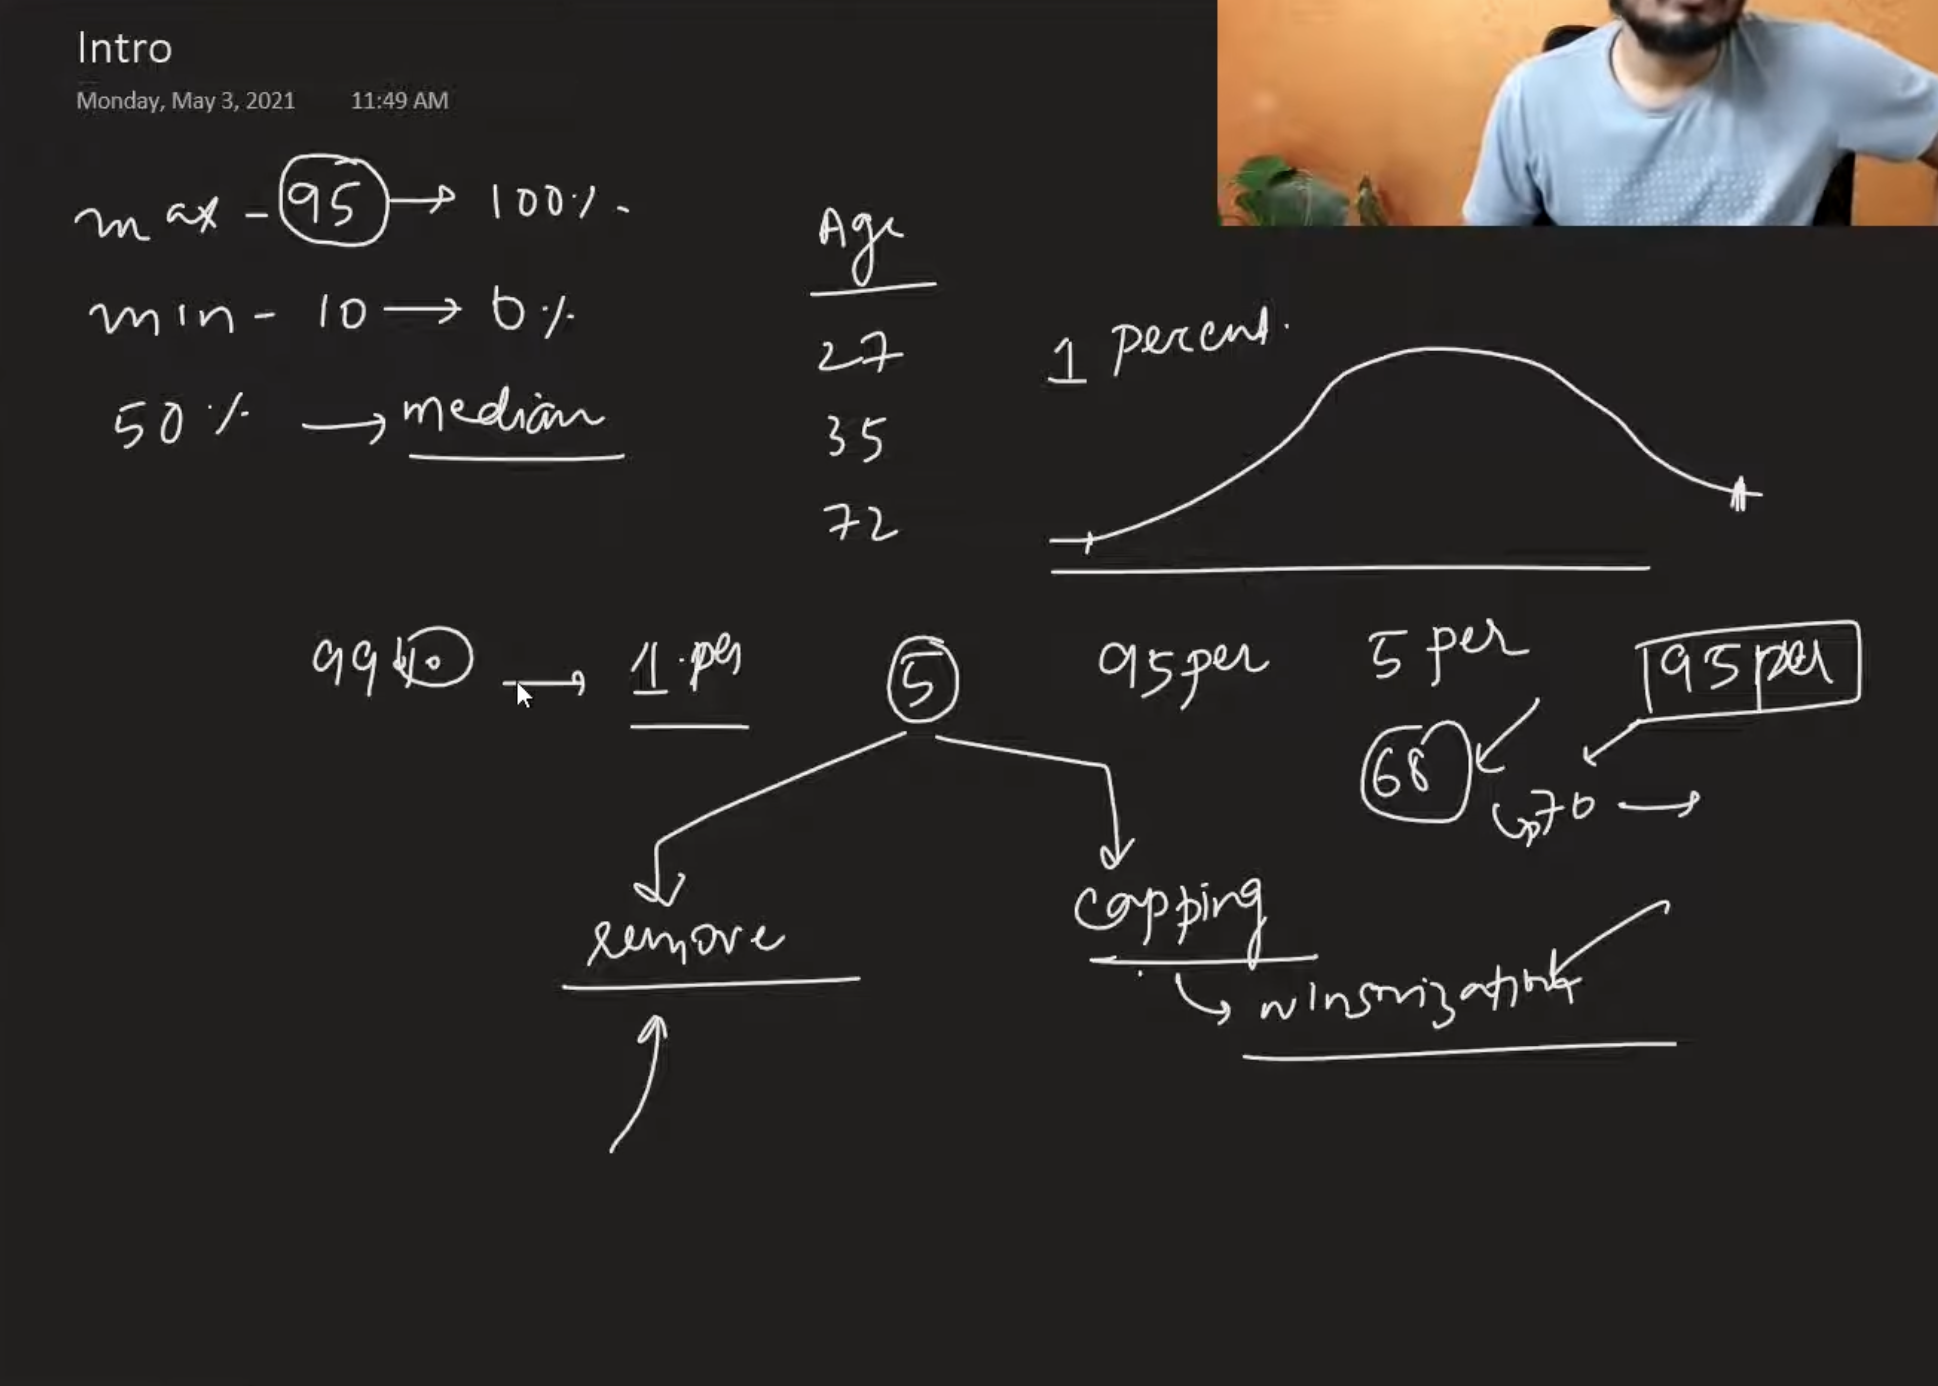

In [50]:
import numpy as np
import pandas as pd

In [51]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day44-outlier-detection-using-percentiles/weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [52]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


<Axes: >

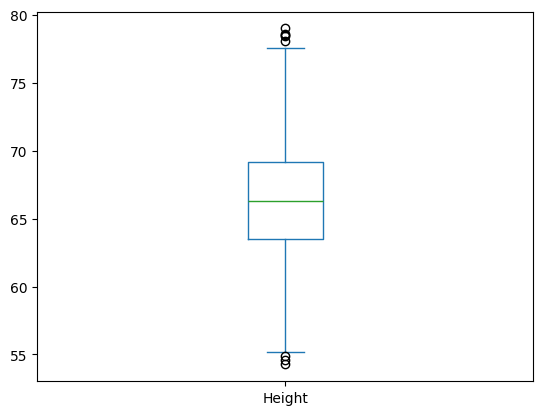

In [53]:
df['Height'].plot(kind='box')

<Axes: ylabel='Density'>

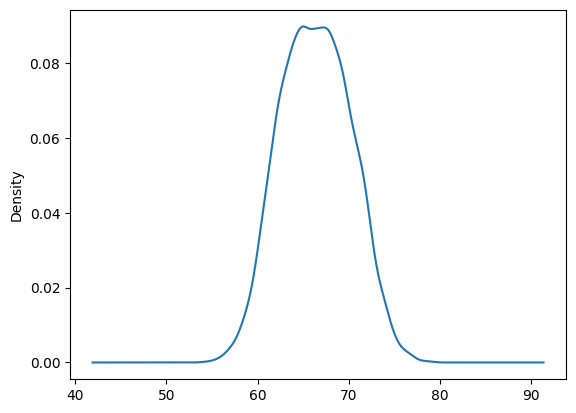

In [54]:
df['Height'].plot(kind='kde')

<Axes: >

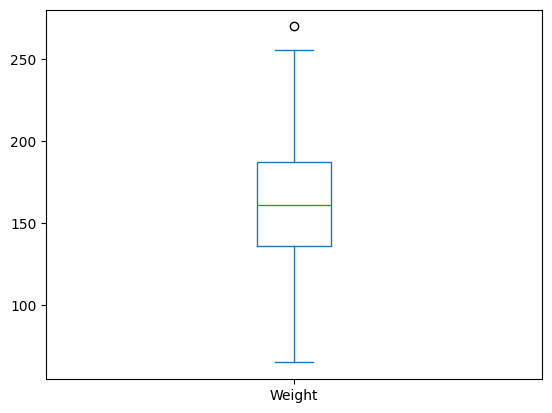

In [55]:
df['Weight'].plot(kind='box')

In [56]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


In [57]:
df['Weight'].describe()

,Weight
count,10000.000000
mean,161.440357
std,32.108439
min,64.700127
25%,135.818051
50%,161.212928
75%,187.169525
max,269.989699


In [58]:
df['Weight'].quantile(0.95)

np.float64(211.76755583198874)

In [59]:
df.sort_values(by='Weight', ascending=False)

,Gender,Height,Weight
2014,Male,78.998742,269.989699
1610,Male,76.617546,255.863326
994,Male,78.095867,255.690835
4331,Male,76.848761,254.209073
3285,Male,78.528210,253.889004
...,...,...,...
7935,Female,58.211650,77.523774
9566,Female,57.353093,72.750145
6624,Female,54.616858,71.393749
5360,Female,55.668202,68.982530


In [60]:
df['Weight']

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801
...,...
9995,136.777454
9996,170.867906
9997,128.475319
9998,163.852461


In [61]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [62]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [63]:
# Upar jitna percentile chore utna hi neeche percentile chorna hoga

In [64]:
df[(df['Height'] >= 74.78) | (df['Height'] <= 58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [65]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [66]:
new_df.describe()

,Height,Weight
count,9799.000000,9799.000000
mean,66.363507,161.391522
std,3.644267,30.925072
min,58.134496,77.523774
25%,63.577147,136.320936
50%,66.317899,161.201891
75%,69.119859,186.747036
max,74.767447,249.946283


<Axes: >

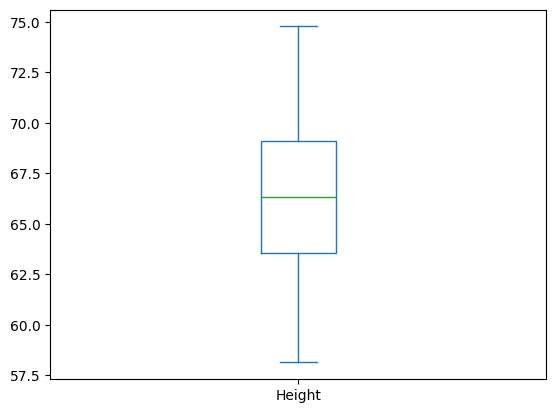

In [67]:
new_df['Height'].plot(kind='box') # no outliers

<Axes: ylabel='Density'>

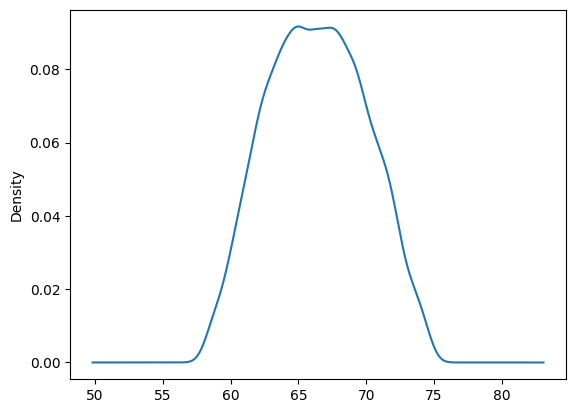

In [68]:
new_df['Height'].plot(kind='kde') # thicker

In [70]:
# Capping --> winsorization

df['Height'] = np.where((df['Height'] >= upper_limit),
         (upper_limit),
         np.where((df['Height'] <= lower_limit),
         (lower_limit),
         (df['Height'])
         ))

<Axes: >

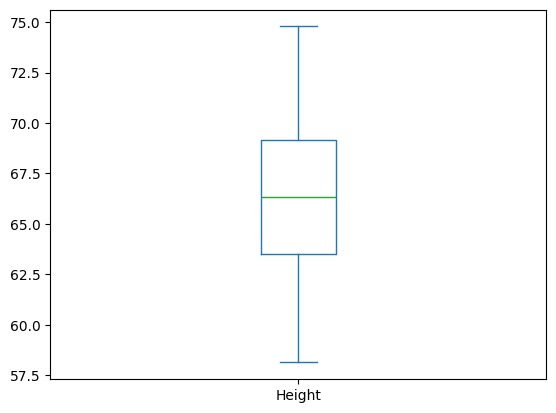

In [72]:
df['Height'].plot(kind='box') # no outliers

<Axes: ylabel='Density'>

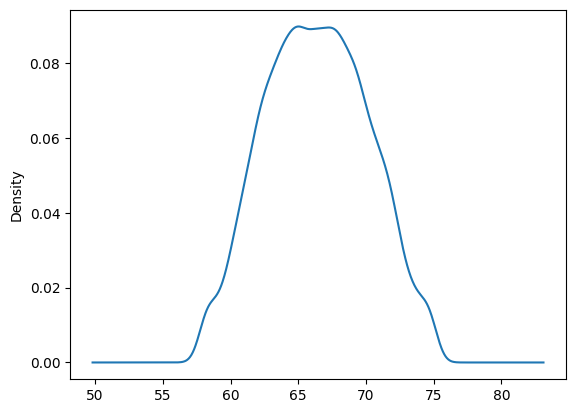

In [73]:
df['Height'].plot(kind='kde')